In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import plotly.express as px
%matplotlib inline


In [49]:
df=pd.read_csv("cricket_knn_indian_players.csv")
df.head()

,temperature,wind_speed,opposition_strength,pitch_dry,pitch_dusty,pitch_green,pitch_hard,best_batter
0,16.637259,4.421072,8,True,False,False,False,1
1,29.622614,24.041788,2,True,False,False,False,1
2,33.223549,11.592342,6,False,False,True,False,3
3,20.340980,8.765273,7,True,False,False,False,1
4,24.992762,26.830270,3,True,False,False,False,1


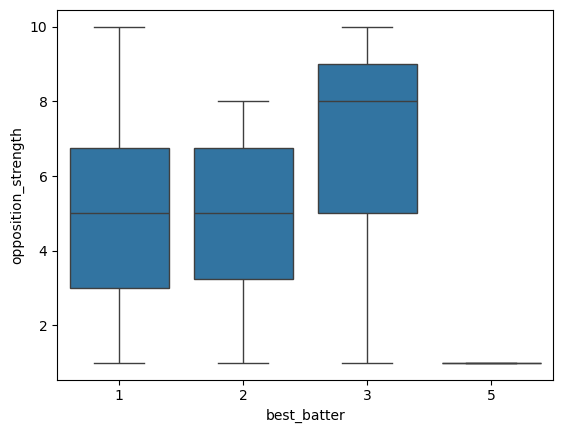

In [57]:
sb.boxplot(x='best_batter',y="opposition_strength", data=df)
plt.show()

In [51]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df_transformed = pt.fit_transform(df.drop("best_batter", axis=1))
df_1 = pd.DataFrame(df_transformed, columns=df.columns[:-1])
df_1["best_batter"] = df["best_batter"].values
df_1

,temperature,wind_speed,opposition_strength,pitch_dry,pitch_dusty,pitch_green,pitch_hard,best_batter
0,-1.560975,-1.151707,0.880840,1.750726,-0.571192,-0.598912,-0.568112,1
1,0.185576,1.067350,-1.280192,1.750726,-0.571192,-0.598912,-0.568112,1
2,0.682310,-0.201572,0.212392,-0.571192,-0.571192,1.669694,-0.568112,3
3,-1.071126,-0.544706,0.551220,1.750726,-0.571192,-0.598912,-0.568112,1
4,-0.445947,1.317471,-0.879293,1.750726,-0.571192,-0.598912,-0.568112,1
...,...,...,...,...,...,...,...,...
495,0.479093,-0.630948,0.880840,1.750726,-0.571192,-0.598912,-0.568112,1
496,-1.499837,1.270088,1.517136,-0.571192,-0.571192,-0.598912,1.760216,3
497,-0.447861,0.754598,0.880840,1.750726,-0.571192,-0.598912,-0.568112,3
498,0.632476,0.671514,-0.500075,1.750726,-0.571192,-0.598912,-0.568112,1


In [52]:
from sklearn.model_selection import train_test_split

X = df_1.drop("best_batter", axis=1)
y = df_1["best_batter"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [55]:
y_pred = model.predict(X_test)


In [56]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.76      0.67      0.72        58
           2       0.00      0.00      0.00         2
           3       0.57      0.70      0.63        40

    accuracy                           0.67       100
   macro avg       0.45      0.46      0.45       100
weighted avg       0.67      0.67      0.67       100

[[39  0 19]
 [ 0  0  2]
 [12  0 28]]


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
lr_cr=classification_report(y_test, y_pred) 
lr_cm=confusion_matrix(y_test, y_pred)

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
